# Reranking 평가

- **입력**: `evaluation/dataset/goldset_final.json`, `evaluation/dataset/scenario_data.json`
- **방법**: goldset의 hybrid 결과를 input으로 CLOVA Reranker API 호출 → before/after 비교
- **Relevant 기준**: `final_grade >= 2`
- **지표**: Hit@K, Recall@K, MRR@K, NDCG@K (K=5, 10, 20)
- **출력**: `evaluation/results/reranking_metrics.png`

> **테스트**: Cell 2의 `LIMIT = 3` 설정 후 실행  
> **전체**: `LIMIT = None` 으로 설정 후 실행

In [1]:
import os
os.chdir("/Users/shimsomin/Workplace/git_workspace/librAIan/backend")

import sys
import json
import asyncio
import uuid
import nest_asyncio
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore')

from app.core.config import settings
from app.modules.reranker.clova_reranker import (
    build_clova_query,
    build_document_text,
    call_clova_reranker,
    extract_clova_scores,
    rerank_by_clova_score,
)

REPO_ROOT = Path("/Users/shimsomin/Workplace/git_workspace/librAIan")
sys.path.insert(0, str(REPO_ROOT / "evaluation" / "metrics"))
from metrics import hit_at_k, recall_at_k, mrr_at_k, ndcg_at_k

nest_asyncio.apply()

/opt/homebrew/Caskroom/miniforge/base/envs/crawler/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATASET_DIR        = REPO_ROOT / "evaluation" / "dataset"
RESULTS_DIR        = REPO_ROOT / "evaluation" / "results"
RESULTS_DIR.mkdir(exist_ok=True)

GOLDSET_PATH       = DATASET_DIR / "goldset_final.json"
SCENARIO_PATH      = DATASET_DIR / "scenario_data.json"

CLOVA_API_KEY      = settings.CLOVA_API_KEY
RELEVANT_THRESHOLD = 2
K_VALUES           = [5, 10, 20]
RERANK_SOURCE      = "hybrid"    # reranking input으로 사용할 retriever
RERANK_CONCURRENCY = 5
LIMIT              = None        # 테스트: 3, 전체: None

print(f"GOLDSET_PATH:  {GOLDSET_PATH}")
print(f"SCENARIO_PATH: {SCENARIO_PATH}")
print(f"CONCURRENCY:   {RERANK_CONCURRENCY}")
print(f"LIMIT:         {LIMIT}")

GOLDSET_PATH:  /Users/shimsomin/Workplace/git_workspace/librAIan/evaluation/dataset/goldset_final.json
SCENARIO_PATH: /Users/shimsomin/Workplace/git_workspace/librAIan/evaluation/dataset/scenario_data.json
CONCURRENCY:   5
LIMIT:         None


In [3]:
with open(GOLDSET_PATH, encoding="utf-8") as f:
    goldset = json.load(f)

with open(SCENARIO_PATH, encoding="utf-8") as f:
    scenarios = json.load(f)

# query_map: scenario_id → rag_query (마지막 turn)
query_map = {}
for s in scenarios:
    rq = s["turns"][-1]["rag_query"].copy()
    rq["query_id"] = s["scenario_id"]
    query_map[s["scenario_id"]] = rq

print(f"goldset: {len(goldset):,}  시나리오: {len(query_map)}")

goldset: 1,698  시나리오: 21


## Eval 구조 빌드

goldset에서 시나리오별로:
- `relevant_isbns`: `final_grade >= 2`인 ISBN 목록
- `hybrid`: `(rank, isbn, score)` 리스트 (rank 오름차순)
- `books`: isbn → 전체 메타데이터 (reranker document 생성용)

In [4]:
eval_data = {}

for book in goldset:
    qid  = book.get("query_id")
    isbn = book.get("isbn")
    if not qid or not isbn:
        continue

    if qid not in eval_data:
        eval_data[qid] = {"relevant_isbns": [], "hybrid": [], "books": {}}

    if book.get("final_grade", -1) >= RELEVANT_THRESHOLD:
        eval_data[qid]["relevant_isbns"].append(isbn)

    for ri in book.get("retrieval_info", []):
        if ri.get("source") == RERANK_SOURCE and ri.get("rank") is not None:
            eval_data[qid]["hybrid"].append(
                (ri["rank"], isbn, ri.get("score", 0.0))
            )

    eval_data[qid]["books"][isbn] = book

for qid in eval_data:
    eval_data[qid]["hybrid"] = sorted(eval_data[qid]["hybrid"])  # (rank, isbn, score)

print(f"{'query_id':>10} {'relevant':>9} {'hybrid_candidates':>18}")
print("-" * 42)
for qid in sorted(eval_data):
    d = eval_data[qid]
    print(f"{qid:>10} {len(d['relevant_isbns']):>9} {len(d['hybrid']):>18}")

  query_id  relevant  hybrid_candidates
------------------------------------------
       S01         7                 39
       S02         6                 40
       S03         0                 40
       S04         9                 40
       S05         3                 40
       S06        29                 39
       S07         9                 39
       S08         3                 40
       S09         9                 40
       S10        27                 39
       S11         6                 40
       S12        40                 38
       S13        11                 40
       S14        10                 40
       S15         2                 40
       S16        13                 40
       S17        22                 38
       S18        34                 37
       S19        37                 40
       S20        12                 39
       S21        18                 40


## Reranking 헬퍼 함수

In [5]:
def rerank_one_scenario(qid, rag_query, eval_data):
    """
    CLOVA Reranker API 호출 → reranked isbn list 반환.
    goldset 메타데이터를 직접 사용하므로 DB 호출 없음.
    """
    candidates = eval_data[qid]["hybrid"]   # [(rank, isbn, score), ...]
    books_meta = eval_data[qid]["books"]

    if not candidates:
        return []

    # CLOVA 쿼리 생성
    query_text = build_clova_query(rag_query)

    # Document 목록 생성
    # goldset large_cate/mid_cate/small_cate → reranker category 필드 매핑
    candidate_books = []
    documents = []
    for rank, isbn, score in candidates:
        book = books_meta.get(isbn)
        if not book:
            continue
        adapted = {
            **book,
            "category": (
                book.get("large_cate", []) +
                book.get("mid_cate", []) +
                book.get("small_cate", [])
            ),
            "rank":  rank,
            "score": score,
        }
        doc_text = build_document_text(adapted, rank, score)
        documents.append({"id": f"{isbn}__rank_{rank}", "text": doc_text})
        candidate_books.append(adapted)

    payload        = {"query": query_text, "documents": documents}
    clova_response = call_clova_reranker(
        payload,
        api_key=CLOVA_API_KEY,
        request_id=str(uuid.uuid4()),
        api_url="https://clovastudio.stream.ntruss.com/v1/api-tools/reranker",
    )
    clova_scores = extract_clova_scores(clova_response)
    reranked     = rerank_by_clova_score(candidate_books, clova_scores)
    return [b["isbn"] for b in reranked.get("reranked_books", [])]

## Reranking 실행 (Async)

> **테스트**: Cell 2의 `LIMIT = 3`으로 설정 후 실행  
> **전체**: `LIMIT = None`으로 설정 후 실행

In [6]:
async def run_reranking_eval():
    qids = [qid for qid in eval_data if qid in query_map]
    if LIMIT:
        qids = qids[:LIMIT]

    semaphore        = asyncio.Semaphore(RERANK_CONCURRENCY)
    reranked_results = {}
    pbar             = tqdm(total=len(qids), desc="Reranking", unit="scenario")

    async def rerank_async(qid):
        async with semaphore:
            try:
                reranked_results[qid] = await asyncio.to_thread(
                    rerank_one_scenario,
                    qid,
                    query_map[qid],
                    eval_data,
                )
            except Exception as e:
                print(f"[{qid}] 오류: {e}")
                reranked_results[qid] = []
        pbar.update(1)

    await asyncio.gather(*[rerank_async(qid) for qid in qids])
    pbar.close()
    return reranked_results


reranked_results = await run_reranking_eval()
print(f"완료: {len(reranked_results)}개 시나리오")

Reranking:  29%|██▊       | 6/21 [00:00<00:00, 19.18scenario/s]

[S03] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S15] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S20] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S02] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S05] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S12] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S09] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S18] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S21] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker


Reranking:  71%|███████▏  | 15/21 [00:00<00:00, 24.21scenario/s]

[S19] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S16] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S07] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S13] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S08] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S01] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S17] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker


Reranking: 100%|██████████| 21/21 [00:00<00:00, 24.90scenario/s]

[S11] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S10] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S06] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S14] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
[S04] 오류: 400 Client Error: Bad Request for url: https://clovastudio.stream.ntruss.com/v1/api-tools/reranker
완료: 21개 시나리오


## Before / After 비교

In [7]:
def compute_rerank_metrics(eval_data, reranked_results, ks=K_VALUES):
    rows = []
    for qid, reranked in reranked_results.items():
        rel    = eval_data[qid]["relevant_isbns"]
        before = [isbn for _, isbn, _ in eval_data[qid]["hybrid"]]
        if not rel or not before:
            continue
        for k in ks:
            for stage, ranked in [("before", before), ("after", reranked)]:
                if not ranked:
                    continue
                rows.append({
                    "query_id": qid,
                    "k":        k,
                    "stage":    stage,
                    "hit":    hit_at_k(rel, ranked, k),
                    "recall": recall_at_k(rel, ranked, k),
                    "mrr":    mrr_at_k(rel, ranked, k),
                    "ndcg":   ndcg_at_k(rel, ranked, k),
                })
    return pd.DataFrame(rows)


rerank_df      = compute_rerank_metrics(eval_data, reranked_results)
rerank_summary = (
    rerank_df
    .groupby(["stage", "k"])[["hit", "recall", "mrr", "ndcg"]]
    .mean()
    .round(4)
)
print("[Before / After Reranking 평균 성능]")
print(rerank_summary.to_string())

[Before / After Reranking 평균 성능]
            hit  recall     mrr    ndcg
stage  k                               
before 5   0.75  0.1663  0.4975  0.3691
       10  0.90  0.2364  0.5168  0.3457
       20  0.95  0.3337  0.5213  0.3651


저장 완료: /Users/shimsomin/Workplace/git_workspace/librAIan/evaluation/results/reranking_metrics.png


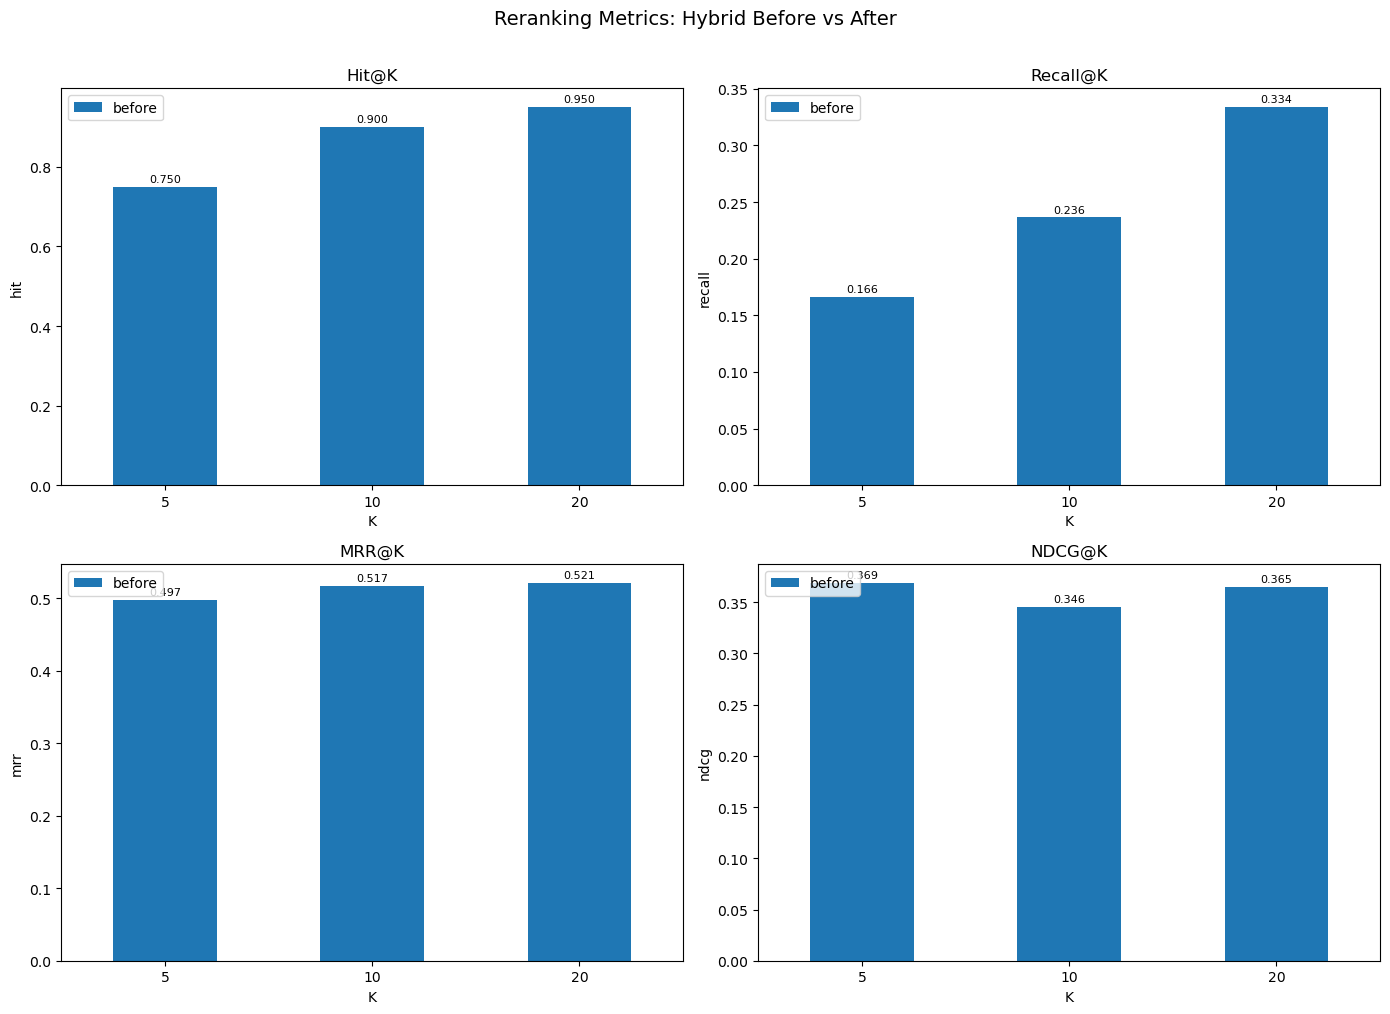

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Reranking Metrics: Hybrid Before vs After", fontsize=14, y=1.01)

for ax, metric, title in zip(
    axes.flat,
    ["hit", "recall", "mrr", "ndcg"],
    ["Hit@K", "Recall@K", "MRR@K", "NDCG@K"],
):
    # stage 컬럼 순서: before → after
    stages = [s for s in ["before", "after"] if s in rerank_summary[metric].unstack("stage").columns]
    pivot  = rerank_summary[metric].unstack("stage")[stages]
    pivot.plot(kind="bar", ax=ax, title=title, rot=0)
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.legend(loc="upper left")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)

plt.tight_layout()
save_path = RESULTS_DIR / "reranking_metrics.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"저장 완료: {save_path}")
plt.show()